<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/week2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ============================================================
# WEEK 2 — Tier 1: Attention U-Net Baseline
# ============================================================
# Purpose: sanity-check the data pipeline, training loop, and
# evaluation code (Dice/IoU/Precision/Recall/Specificity/HD95)
# on a simple, well-documented architecture before building
# D-SAS's custom modules (SSBG, AAS, SFH) in Week 3+.
#
# Dataset: BUSI, deduplicated (527 images), split 368/78/81
# Result:  Dice 0.7215 | IoU 0.5698 | Precision 0.7999
#          Recall 0.6629 | Specificity 0.9780
# ============================================================

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, csv, json, hashlib, random
from collections import defaultdict
from itertools import combinations

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy.ndimage import distance_transform_edt, binary_erosion

print("CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "Switch runtime to GPU: Runtime -> Change runtime type -> GPU"

random.seed(42)

RAW_ROOT = '/content/data/Dataset_BUSI_with_GT'
CLASSES = ['benign', 'malignant']
NEAR_DUP_THRESHOLD = 5
IMG_SIZE = 256
FINAL_DIR = '/content/drive/MyDrive/BUSI_Dataset'
PROJECT_DIR = f'{FINAL_DIR}/tier1_attention_unet'
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs', exist_ok=True)

Mounted at /content/drive
CUDA available: True


In [2]:
if not os.path.exists(RAW_ROOT):
    from google.colab import userdata
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    os.makedirs("/content/data", exist_ok=True)
    os.system("pip install -q -U kaggle")
    os.system(
        "kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset "
        "-p /content/data --unzip"
    )
print("Raw dataset present:", os.path.exists(RAW_ROOT))

Raw dataset present: True


In [3]:
try:
    import imagehash
except ImportError:
    os.system("pip install -q ImageHash")
    import imagehash

def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls, 'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records

def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()

def phash(filepath):
    return imagehash.phash(Image.open(filepath).convert('L'))

def find_exact_duplicate_groups(records):
    groups = defaultdict(list)
    for r in records:
        groups[md5_hash(r['image_path'])].append(r)
    return [g for g in groups.values() if len(g) > 1]

def find_near_duplicate_pairs(records, threshold):
    hashes = [(r, phash(r['image_path'])) for r in records]
    pairs = []
    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        if h_a - h_b <= threshold:
            pairs.append((r_a, r_b, h_a - h_b))
    return pairs

class UnionFind:
    def __init__(self, items):
        self.parent = {id(item): item for item in items}
    def find(self, item):
        pid = id(item)
        while self.parent[pid] is not item:
            item = self.parent[pid]; pid = id(item)
        return item
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra is not rb:
            self.parent[id(ra)] = rb

def group_near_duplicates(records, pairs):
    uf = UnionFind(records)
    for r_a, r_b, _ in pairs:
        uf.union(r_a, r_b)
    groups = defaultdict(list)
    for r in records:
        groups[id(uf.find(r))].append(r)
    return [g for g in groups.values() if len(g) > 1]

print("Collecting image records...")
records = collect_images(RAW_ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

exact_groups = find_exact_duplicate_groups(records)
print(f"Exact duplicate groups: {len(exact_groups)}")

near_pairs = find_near_duplicate_pairs(records, NEAR_DUP_THRESHOLD)
near_groups = group_near_duplicates(records, near_pairs)
print(f"Near-duplicate groups: {len(near_groups)}")

same_class_groups, cross_class_groups = [], []
for g in near_groups:
    (cross_class_groups if len({r['class'] for r in g}) > 1 else same_class_groups).append(g)
print(f"Same-class groups: {len(same_class_groups)} | Cross-class conflicts: {len(cross_class_groups)}")

excluded_paths = {r['image_path'] for g in cross_class_groups for r in g}
kept_records, seen_paths = [], set()
for g in same_class_groups:
    kept_records.append(g[0]); seen_paths.add(g[0]['image_path'])
    for r in g[1:]:
        seen_paths.add(r['image_path'])
for r in records:
    if r['image_path'] not in excluded_paths and r['image_path'] not in seen_paths:
        kept_records.append(r)

print(f"\nFinal deduplicated dataset: {len(kept_records)} images (removed {len(records) - len(kept_records)})")
for cls in CLASSES:
    n = sum(1 for r in kept_records if r['class'] == cls)
    print(f"  {cls}: {n}")

Total benign+malignant images: 647
Exact duplicate groups: 1
Near-duplicate groups: 98
Same-class groups: 92 | Cross-class conflicts: 6

Final deduplicated dataset: 527 images (removed 120)
  benign: 334
  malignant: 193


In [4]:
def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []
    for cls in classes:
        cls_records = [r for r in records if r['class'] == cls]
        random.shuffle(cls_records)
        n = len(cls_records)
        n_train, n_val = int(n * ratios[0]), int(n * ratios[1])
        train.extend(cls_records[:n_train])
        val.extend(cls_records[n_train:n_train + n_val])
        test.extend(cls_records[n_train + n_val:])
    random.shuffle(train); random.shuffle(val); random.shuffle(test)
    return train, val, test

def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['class', 'image_path', 'mask_paths'])
        for r in records:
            writer.writerow([r['class'], r['image_path'], '|'.join(r['mask_paths'])])

train_records, val_records, test_records = stratified_split(kept_records, CLASSES)
print(f"Split — train: {len(train_records)}, val: {len(val_records)}, test: {len(test_records)}")

save_split_csv(f'{FINAL_DIR}/train.csv', train_records)
save_split_csv(f'{FINAL_DIR}/val.csv', val_records)
save_split_csv(f'{FINAL_DIR}/test.csv', test_records)
print(f"Splits saved to {FINAL_DIR}")

Split — train: 368, val: 78, test: 81
Splits saved to /content/drive/MyDrive/BUSI_Dataset


In [5]:
def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_eval_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class BUSISegmentationDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.records = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []
                self.records.append({'class': row['class'], 'image_path': row['image_path'], 'mask_paths': mask_paths})
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        record = self.records[idx]
        image = np.array(Image.open(record['image_path']).convert('RGB'))
        mask = None
        for mp in record['mask_paths']:
            m = (np.array(Image.open(mp).convert('L')) > 0).astype(np.uint8)
            mask = m if mask is None else np.maximum(mask, m)
        if mask is None:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask'].unsqueeze(0).float()
        return {'image': image, 'mask': mask, 'class': record['class']}

def get_dataloaders(splits_dir, batch_size=16, img_size=IMG_SIZE, num_workers=2):
    train_ds = BUSISegmentationDataset(f'{splits_dir}/train.csv', transform=get_train_transform(img_size))
    val_ds = BUSISegmentationDataset(f'{splits_dir}/val.csv', transform=get_eval_transform(img_size))
    test_ds = BUSISegmentationDataset(f'{splits_dir}/test.csv', transform=get_eval_transform(img_size))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(FINAL_DIR)
_batch = next(iter(train_loader))
print("Sanity check — Image shape:", _batch["image"].shape, "| Mask shape:", _batch["mask"].shape)

Train: 368 | Val: 78 | Test: 81
Sanity check — Image shape: torch.Size([16, 3, 256, 256]) | Mask shape: torch.Size([16, 1, 256, 256])


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.enc1 = ConvBlock(in_ch, features[0])
        self.enc2 = ConvBlock(features[0], features[1])
        self.enc3 = ConvBlock(features[1], features[2])
        self.enc4 = ConvBlock(features[2], features[3])
        self.bottleneck = ConvBlock(features[3], features[3] * 2)
        self.up4 = nn.ConvTranspose2d(features[3] * 2, features[3], 2, stride=2)
        self.att4 = AttentionGate(features[3], features[3], features[3] // 2)
        self.dec4 = ConvBlock(features[3] * 2, features[3])
        self.up3 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)
        self.att3 = AttentionGate(features[2], features[2], features[2] // 2)
        self.dec3 = ConvBlock(features[2] * 2, features[2])
        self.up2 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.att2 = AttentionGate(features[1], features[1], features[1] // 2)
        self.dec2 = ConvBlock(features[1] * 2, features[1])
        self.up1 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.att1 = AttentionGate(features[0], features[0], features[0] // 2)
        self.dec1 = ConvBlock(features[0] * 2, features[0])
        self.final = nn.Conv2d(features[0], out_ch, kernel_size=1)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, self.att4(g=d4, x=e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self.att3(g=d3, x=e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self.att2(g=d2, x=e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self.att1(g=d1, x=e1)], dim=1))
        return self.final(d1)

print("Model defined")

Model defined


In [7]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, pred_logits, target):
        bce_loss = self.bce(pred_logits, target)
        pred = torch.sigmoid(pred_logits)
        pf, tf = pred.view(-1), target.view(-1)
        intersection = (pf * tf).sum()
        dice_loss = 1 - (2 * intersection + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
        return bce_loss + dice_loss

def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum(); fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum(); tn = ((1 - pred) * (1 - target)).sum()
    dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    specificity = (tn + 1e-6) / (tn + fp + 1e-6)
    return {"dice": dice.item(), "iou": iou.item(), "precision": precision.item(), "recall": recall.item(), "specificity": specificity.item()}

def compute_hd95_single(pred_mask, gt_mask):
    if not pred_mask.any() or not gt_mask.any():
        return None
    pred_border = pred_mask ^ binary_erosion(pred_mask)
    gt_border = gt_mask ^ binary_erosion(gt_mask)
    dt_gt = distance_transform_edt(~gt_border)
    dt_pred = distance_transform_edt(~pred_border)
    d_pred_to_gt = dt_gt[pred_border]
    d_gt_to_pred = dt_pred[gt_border]
    return max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        images, masks = batch["image"].to(device), batch["mask"].to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_metrics, hd95_values = 0, [], []
    with torch.no_grad():
        for batch in loader:
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            all_metrics.append(compute_metrics(preds, masks))
            pred_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().astype(bool)
            gt_bin = masks.cpu().numpy().astype(bool)
            for i in range(pred_bin.shape[0]):
                hd = compute_hd95_single(pred_bin[i, 0], gt_bin[i, 0])
                if hd is not None:
                    hd95_values.append(hd)
    avg = {k: sum(m[k] for m in all_metrics) / len(all_metrics) for k in all_metrics[0]}
    avg['hd95_mean'] = float(np.mean(hd95_values)) if hd95_values else float('nan')
    avg['hd95_median'] = float(np.median(hd95_values)) if hd95_values else float('nan')
    avg['hd95_valid_count'] = len(hd95_values)
    return total_loss / len(loader), avg

print("Loss, metrics, train/validate functions defined")

Loss, metrics, train/validate functions defined


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = AttentionUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = DiceBCELoss()

NUM_EPOCHS, PATIENCE = 50, 10
best_val_dice, epochs_no_improve = 0.0, 0
checkpoint_path = f'{PROJECT_DIR}/checkpoints/attention_unet_best.pth'
history = []

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_metrics = validate(model, val_loader, loss_fn, device)
    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | {time.time()-start:.1f}s")
    if val_metrics['dice'] > best_val_dice:
        best_val_dice, epochs_no_improve = val_metrics['dice'], 0
        torch.save(model.state_dict(), checkpoint_path)
        print("  -> new best, checkpoint saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

pd.DataFrame(history).to_csv(f'{PROJECT_DIR}/logs/training_history.csv', index=False)
print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/50 | train_loss: 1.4127 | val_loss: 1.4766 | val_dice: 0.2263 | val_iou: 0.1281 | 25.8s
  -> new best, checkpoint saved
Epoch 2/50 | train_loss: 1.2366 | val_loss: 1.2270 | val_dice: 0.4510 | val_iou: 0.2912 | 23.5s
  -> new best, checkpoint saved
Epoch 3/50 | train_loss: 1.1382 | val_loss: 1.1385 | val_dice: 0.4159 | val_iou: 0.2662 | 23.4s
Epoch 4/50 | train_loss: 1.0746 | val_loss: 1.1926 | val_dice: 0.4491 | val_iou: 0.2901 | 25.0s
Epoch 5/50 | train_loss: 1.0231 | val_loss: 1.0065 | val_dice: 0.6210 | val_iou: 0.4506 | 24.9s
  -> new best, checkpoint saved
Epoch 6/50 | train_loss: 1.0004 | val_loss: 0.9893 | val_dice: 0.6269 | val_iou: 0.4577 | 26.6s
  -> new best, checkpoint saved
Epoch 7/50 | train_loss: 0.9678 | val_loss: 0.9645 | val_dice: 0.6320 | val_iou: 0.4622 | 28.4s
  -> new best, checkpoint saved
Epoch 8/50 | train_loss: 0.9279 | val_loss: 0.9494 | val_dice: 0.6490 | val_iou: 0.4804 | 29.0s
  -> new best, checkpoint saved
Epoch 9/50 | train_lo

In [9]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

test_loss, test_metrics = validate(model, test_loader, loss_fn, device)
print("\nTest set results (Tier 1 — Attention U-Net baseline):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

results_summary = {'model': 'Attention U-Net (Tier 1)',
                    'dataset': f'BUSI ({len(kept_records)} images, deduplicated, 70/15/15 split)',
                    **test_metrics}
with open(f'{PROJECT_DIR}/logs/test_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("\nSaved test_results.json")


Test set results (Tier 1 — Attention U-Net baseline):
  dice: 0.7245
  iou: 0.5782
  precision: 0.7297
  recall: 0.7222
  specificity: 0.9620
  hd95_mean: 53.8814
  hd95_median: 34.7248
  hd95_valid_count: 78.0000

Saved test_results.json


In [10]:
FINAL_DIR = '/content/drive/MyDrive/BUSI_Dataset'
train_records = pd.read_csv(f'{FINAL_DIR}/train.csv')
val_records = pd.read_csv(f'{FINAL_DIR}/val.csv')
test_records = pd.read_csv(f'{FINAL_DIR}/test.csv')

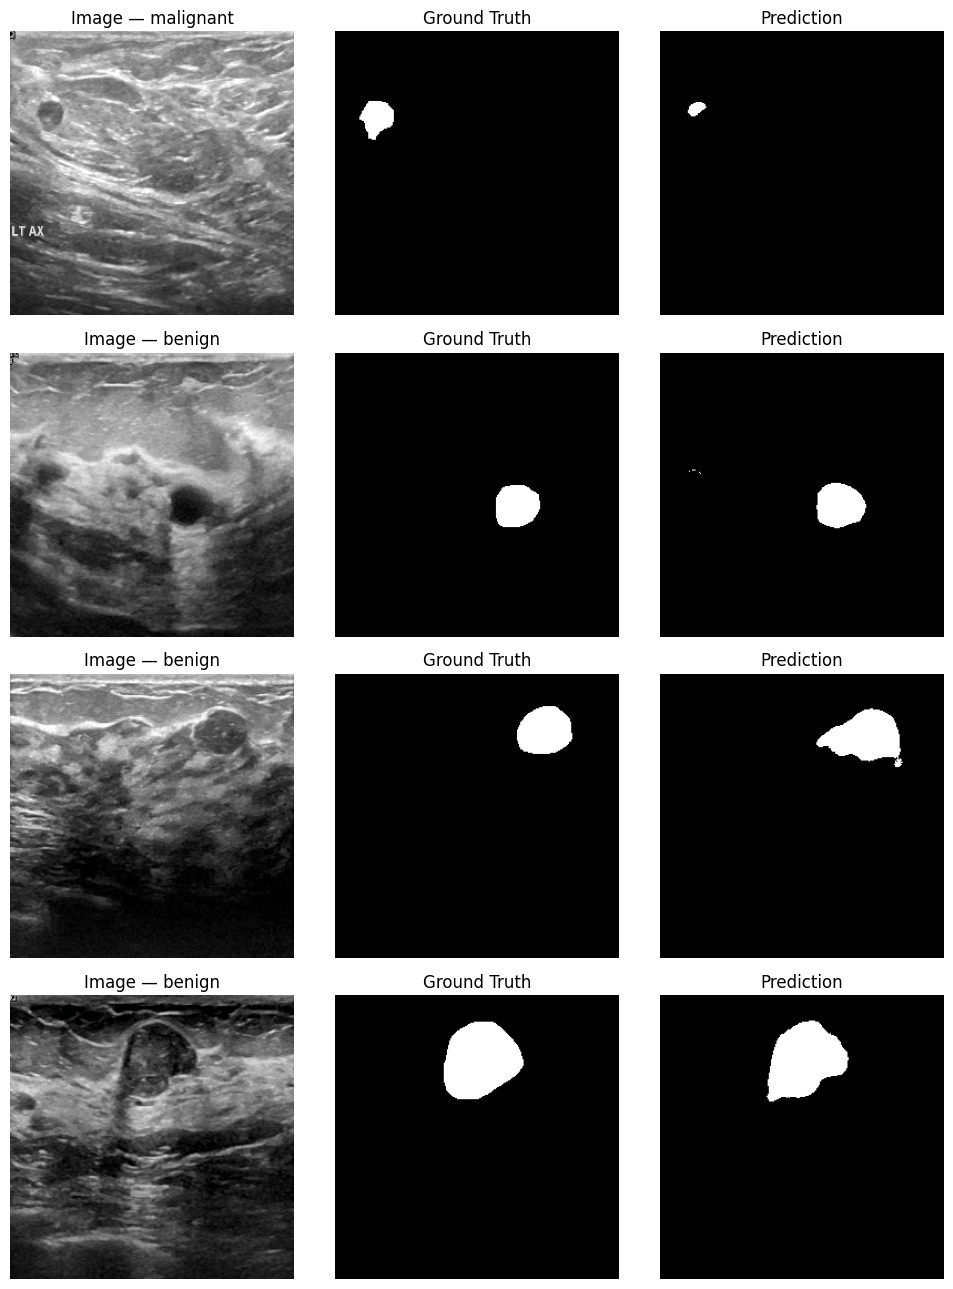

In [11]:
model.eval()
batch = next(iter(test_loader))
images, masks = batch["image"].to(device), batch["mask"].to(device)
with torch.no_grad():
    preds = torch.sigmoid(model(images)) > 0.5

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/logs/sample_predictions.png', dpi=120)
plt.show()

In [13]:
# ============================================================
# WEEK 3 — D-SAS Tier 2: ResNet101 Backbone + SSBG
# ============================================================

In [14]:
import torchvision.models as models

resnet = models.resnet101(weights='IMAGENET1K_V2')
print(resnet)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 164MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
x = torch.randn(1, 3, 256, 256)
x = resnet.maxpool(resnet.relu(resnet.bn1(resnet.conv1(x))))
print("after stem:", x.shape)          # expect [1, 64, 64, 64]

x1 = resnet.layer1(x)
print("layer1:", x1.shape)             # expect [1, 256, 64, 64]  <- 1/4 resolution

x2 = resnet.layer2(x1)
print("layer2:", x2.shape)             # expect [1, 512, 32, 32]

x3 = resnet.layer3(x2)
print("layer3:", x3.shape)             # expect [1, 1024, 16, 16]

x4 = resnet.layer4(x3)
print("layer4:", x4.shape)             # expect [1, 2048, 8, 8]

after stem: torch.Size([1, 64, 64, 64])
layer1: torch.Size([1, 256, 64, 64])
layer2: torch.Size([1, 512, 32, 32])
layer3: torch.Size([1, 1024, 16, 16])
layer4: torch.Size([1, 2048, 8, 8])


In [17]:
def modify_layer4_dilation(resnet):
    for name, module in resnet.layer4.named_modules():
        if isinstance(module, nn.Conv2d) and module.stride == (2, 2):
            module.stride = (1, 1)
            if module.kernel_size == (3, 3):
                # main-path conv: use dilation to preserve receptive field
                module.dilation = (2, 2)
                module.padding = (2, 2)
            # else: 1x1 downsample/shortcut conv — only fix stride,
            # leave padding at 0 (dilation has no effect on a 1x1 kernel anyway)
    return resnet

# Reload a fresh ResNet101 — the previous one is already incorrectly mutated
resnet = models.resnet101(weights='IMAGENET1K_V2')
resnet = modify_layer4_dilation(resnet)

x4 = resnet.layer4(x3)
print("layer4 after fix:", x4.shape)   # expect [1, 2048, 16, 16]

layer4 after fix: torch.Size([1, 2048, 16, 16])


In [18]:
class D_SAS_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet101(weights='IMAGENET1K_V2')
        resnet = modify_layer4_dilation(resnet)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):
        x = self.stem(x)
        f_low = self.layer1(x)      # [B, 256, H/4, W/4]
        x2 = self.layer2(f_low)
        x3 = self.layer3(x2)
        f_high = self.layer4(x3)    # [B, 2048, H/16, W/16]
        return f_low, f_high

backbone = D_SAS_Backbone().to(device)
f_low, f_high = backbone(torch.randn(2, 3, 256, 256).to(device))
print("F_low:", f_low.shape)   # expect [2, 256, 64, 64]
print("F_high:", f_high.shape) # expect [2, 2048, 16, 16]

F_low: torch.Size([2, 256, 64, 64])
F_high: torch.Size([2, 2048, 16, 16])


In [19]:
class ChannelReduce(nn.Module):
    def __init__(self, in_ch, out_ch=256):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

reduce_low = ChannelReduce(256, 256).to(device)
reduce_high = ChannelReduce(2048, 256).to(device)

f_low_reduced = reduce_low(f_low)
f_high_reduced = reduce_high(f_high)
print(f_low_reduced.shape, f_high_reduced.shape)  # expect [2,256,64,64] and [2,256,16,16]

torch.Size([2, 256, 64, 64]) torch.Size([2, 256, 16, 16])


In [20]:
class SSBG(nn.Module):
    def __init__(self, ch, edge_weight=0.1):
        super().__init__()
        self.edge_weight = edge_weight
        self.gate_dw = nn.Conv2d(ch, ch, 3, padding=1, groups=ch)
        self.gate_bn = nn.BatchNorm2d(ch)
        self.gate_pw = nn.Conv2d(ch, 1, 1)
        self.edge_dw = nn.Conv2d(ch, ch, 3, padding=1, groups=ch)
        self.edge_bn1 = nn.BatchNorm2d(ch)
        self.edge_pw = nn.Conv2d(ch, ch, 1)
        self.edge_bn2 = nn.BatchNorm2d(ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, f_low):
        g = self.relu(self.gate_bn(self.gate_dw(f_low)))
        g = torch.sigmoid(self.gate_pw(g))
        f_gated = f_low * g

        e = self.relu(self.edge_bn1(self.edge_dw(f_low)))
        f_edge = self.relu(self.edge_bn2(self.edge_pw(e)))

        return f_gated + f_edge * self.edge_weight

ssbg = SSBG(ch=256).to(device)
f_ssbg = ssbg(f_low_reduced)
print("F_ssbg:", f_ssbg.shape)  # expect [2, 256, 64, 64]

F_ssbg: torch.Size([2, 256, 64, 64])


In [21]:
with torch.no_grad():
    g_test = torch.sigmoid(ssbg.gate_pw(ssbg.relu(ssbg.gate_bn(ssbg.gate_dw(f_low_reduced)))))
    print("Gate min/max:", g_test.min().item(), g_test.max().item())  # expect between 0 and 1

Gate min/max: 0.07671140879392624 0.7920971512794495


In [22]:
model.eval()  # not needed here, but harmless; backbone/ssbg have no batchnorm-sensitive issue with a batch of 1 if using eval mode
backbone.eval()
ssbg.eval()

batch = next(iter(test_loader))
real_image = batch["image"][:1].to(device)  # take just one real image

with torch.no_grad():
    f_low_real, f_high_real = backbone(real_image)
    f_low_real_reduced = reduce_low(f_low_real)
    f_ssbg_real = ssbg(f_low_real_reduced)
    g_real = torch.sigmoid(ssbg.gate_pw(ssbg.relu(ssbg.gate_bn(ssbg.gate_dw(f_low_real_reduced)))))

print("F_ssbg on real image:", f_ssbg_real.shape)
print("Gate map on real image — min/max:", g_real.min().item(), g_real.max().item())

F_ssbg on real image: torch.Size([1, 256, 64, 64])
Gate map on real image — min/max: 0.3698689043521881 0.6716435551643372


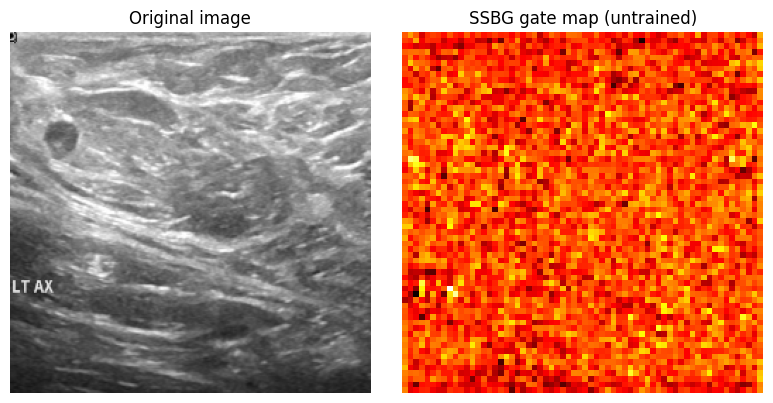

In [23]:
import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = real_image[0].cpu().permute(1, 2, 0).numpy()
img = (img * std + mean).clip(0, 1)

gate_map = g_real[0, 0].cpu().numpy()  # [64, 64]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img); axes[0].set_title("Original image"); axes[0].axis('off')
axes[1].imshow(gate_map, cmap='hot'); axes[1].set_title("SSBG gate map (untrained)"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# WEEK 4 — D-SAS Tier 2: AAS + SFH + Full Model Assembly
# ============================================================
# Purpose: complete the reproduced D-SAS architecture by adding
# the multi-scale semantic branch (AAS) and the boundary-semantic
# fusion module (SFH), then assemble backbone + SSBG + AAS + SFH
# + decoder into one end-to-end model for training in Week 5.
# ============================================================

In [25]:
import torch.nn.functional as F

class AAS(nn.Module):
    def __init__(self, in_ch=256, out_ch=256, dilations=(1, 2, 4, 6)):
        super().__init__()
        self.branches = nn.ModuleList()
        for d in dilations:
            # d=1 gives a standard 3x3 conv; d>1 gives dilated (atrous) convs
            conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=d, dilation=d)
            self.branches.append(nn.Sequential(conv, nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)))

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.global_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

        self.gate = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, 5, 1)  # 5 branches -> 5 weight maps
        )
        self.final = nn.Sequential(nn.Conv2d(out_ch, out_ch, 1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        H, W = x.shape[2], x.shape[3]
        feats = [branch(x) for branch in self.branches]

        global_feat = self.global_conv(self.global_pool(x))
        global_feat = F.interpolate(global_feat, size=(H, W), mode='bilinear', align_corners=False)
        feats.append(global_feat)  # now 5 feature maps total

        concat = torch.cat(feats, dim=1)          # [B, out_ch*5, H, W]
        weights_raw = self.gate(concat)            # [B, 5, H, W]
        weights = torch.softmax(weights_raw, dim=1) # per-pixel weights across the 5 branches

        stacked = torch.stack(feats, dim=1)         # [B, 5, out_ch, H, W]
        weighted_sum = (stacked * weights.unsqueeze(2)).sum(dim=1)  # [B, out_ch, H, W]

        out = self.dropout(self.final(weighted_sum))
        return out

aas = AAS(in_ch=256, out_ch=256).to(device)
f_aas = aas(f_high_reduced)
print("F_aas:", f_aas.shape)  # expect [2, 256, 16, 16]

F_aas: torch.Size([2, 256, 16, 16])


In [26]:
with torch.no_grad():
    H, W = f_high_reduced.shape[2], f_high_reduced.shape[3]
    feats_test = [branch(f_high_reduced) for branch in aas.branches]
    global_feat_test = F.interpolate(aas.global_conv(aas.global_pool(f_high_reduced)), size=(H, W), mode='bilinear', align_corners=False)
    feats_test.append(global_feat_test)
    concat_test = torch.cat(feats_test, dim=1)
    weights_test = torch.softmax(aas.gate(concat_test), dim=1)

    print("Weights shape:", weights_test.shape)          # expect [2, 5, 16, 16]
    print("Sum across branches (should be ~1.0):", weights_test.sum(dim=1)[0,0,0].item())

Weights shape: torch.Size([2, 5, 16, 16])
Sum across branches (should be ~1.0): 1.0


In [27]:
aas.eval()
with torch.no_grad():
    f_low_real, f_high_real = backbone(real_image)
    f_high_real_reduced = reduce_high(f_high_real)
    f_aas_real = aas(f_high_real_reduced)
print("F_aas on real image:", f_aas_real.shape)

F_aas on real image: torch.Size([1, 256, 16, 16])


In [28]:
class SFH(nn.Module):
    def __init__(self, ch=256, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gate_l = nn.Sequential(nn.Conv2d(ch * 2, ch, 1), nn.BatchNorm2d(ch), nn.Sigmoid())
        self.gate_h = nn.Sequential(nn.Conv2d(ch * 2, ch, 1), nn.BatchNorm2d(ch), nn.Sigmoid())
        self.conv_l = nn.Conv2d(ch, 1, 1)
        self.conv_h = nn.Conv2d(ch, 1, 1)
        self.out_proj = nn.Sequential(nn.Conv2d(ch, ch, 1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))

    def forward(self, f_low, f_high):
        f_high_up = F.interpolate(f_high, size=f_low.shape[2:], mode='bilinear', align_corners=False)

        cat_l = torch.cat([f_low, f_high_up], dim=1)
        cat_h = torch.cat([f_high_up, f_low], dim=1)

        g_l = self.gate_l(cat_l)
        g_h = self.gate_h(cat_h)

        f_l_hat = f_low * g_l
        f_h_hat = f_high_up * g_h

        ul = F.softplus(self.conv_l(f_l_hat)) + self.eps
        uh = F.softplus(self.conv_h(f_h_hat)) + self.eps

        fused = (f_l_hat / ul + f_h_hat / uh) / (1 / ul + 1 / uh)
        return self.out_proj(fused)

sfh = SFH(ch=256).to(device)
f_sfh = sfh(f_ssbg, f_aas)
print("F_sfh:", f_sfh.shape)  # expect [2, 256, 64, 64]

F_sfh: torch.Size([2, 256, 64, 64])


In [29]:
with torch.no_grad():
    f_high_up = F.interpolate(f_aas, size=f_ssbg.shape[2:], mode='bilinear', align_corners=False)
    cat_l = torch.cat([f_ssbg, f_high_up], dim=1)
    g_l = sfh.gate_l(cat_l)
    f_l_hat = f_ssbg * g_l
    ul = F.softplus(sfh.conv_l(f_l_hat)) + sfh.eps
    print("ul min/max (should be > 0):", ul.min().item(), ul.max().item())

ul min/max (should be > 0): 0.552040696144104 1.0746822357177734


In [30]:
with torch.no_grad():
    f_ssbg_real = ssbg(f_low_real_reduced) if 'f_low_real_reduced' in dir() else ssbg(reduce_low(f_low_real))
    f_sfh_real = sfh(f_ssbg_real, f_aas_real)
print("F_sfh on real image:", f_sfh_real.shape)

F_sfh on real image: torch.Size([1, 256, 64, 64])


In [31]:
class DSASDecoder(nn.Module):
    def __init__(self, ch=256):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(inplace=True))
        self.final = nn.Conv2d(ch, 1, kernel_size=1)

    def forward(self, x, out_size):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.final(x)
        return F.interpolate(x, size=out_size, mode='bilinear', align_corners=False)


class DSAS(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = D_SAS_Backbone()
        self.reduce_low = ChannelReduce(256, 256)
        self.reduce_high = ChannelReduce(2048, 256)
        self.ssbg = SSBG(ch=256)
        self.aas = AAS(in_ch=256, out_ch=256)
        self.sfh = SFH(ch=256)
        self.decoder = DSASDecoder(ch=256)

    def forward(self, x):
        out_size = x.shape[2:]
        f_low, f_high = self.backbone(x)
        f_low_r = self.reduce_low(f_low)
        f_high_r = self.reduce_high(f_high)
        f_ssbg_out = self.ssbg(f_low_r)
        f_aas_out = self.aas(f_high_r)
        f_sfh_out = self.sfh(f_ssbg_out, f_aas_out)
        return self.decoder(f_sfh_out, out_size)

dsas_model = DSAS().to(device)
test_input = torch.randn(2, 3, 256, 256).to(device)
output = dsas_model(test_input)
print("D-SAS output shape:", output.shape)  # expect [2, 1, 256, 256]
print("Total params:", sum(p.numel() for p in dsas_model.parameters()))

D-SAS output shape: torch.Size([2, 1, 256, 256])
Total params: 47500873


In [32]:
# ============================================================
# WEEK 5 — D-SAS Tier 2: Training and Evaluation
# ============================================================

dsas_model = DSAS().to(device)
optimizer = torch.optim.Adam(dsas_model.parameters(), lr=1e-4)
loss_fn = DiceBCELoss()

DSAS_PROJECT_DIR = f'{FINAL_DIR}/tier2_dsas'
os.makedirs(f'{DSAS_PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DSAS_PROJECT_DIR}/logs', exist_ok=True)

NUM_EPOCHS, PATIENCE = 50, 10
best_val_dice, epochs_no_improve = 0.0, 0
checkpoint_path = f'{DSAS_PROJECT_DIR}/checkpoints/dsas_best.pth'
history = []

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(dsas_model, train_loader, optimizer, loss_fn, device)
    val_loss, val_metrics = validate(dsas_model, val_loader, loss_fn, device)
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss, **val_metrics})
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | {time.time()-start:.1f}s")
    if val_metrics['dice'] > best_val_dice:
        best_val_dice, epochs_no_improve = val_metrics['dice'], 0
        torch.save(dsas_model.state_dict(), checkpoint_path)
        print("  -> new best, saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

pd.DataFrame(history).to_csv(f'{DSAS_PROJECT_DIR}/logs/training_history.csv', index=False)
print(f"\nD-SAS training complete. Best val Dice: {best_val_dice:.4f}")

Epoch 1/50 | train_loss: 1.2112 | val_loss: 1.3327 | val_dice: 0.0005 | val_iou: 0.0002 | 16.9s
  -> new best, saved
Epoch 2/50 | train_loss: 0.8750 | val_loss: 0.9431 | val_dice: 0.5783 | val_iou: 0.4079 | 16.5s
  -> new best, saved
Epoch 3/50 | train_loss: 0.7012 | val_loss: 0.7228 | val_dice: 0.6623 | val_iou: 0.4970 | 17.5s
  -> new best, saved
Epoch 4/50 | train_loss: 0.5970 | val_loss: 0.6727 | val_dice: 0.6669 | val_iou: 0.5024 | 19.3s
  -> new best, saved
Epoch 5/50 | train_loss: 0.5559 | val_loss: 0.5982 | val_dice: 0.7007 | val_iou: 0.5408 | 18.7s
  -> new best, saved
Epoch 6/50 | train_loss: 0.4666 | val_loss: 0.5915 | val_dice: 0.7025 | val_iou: 0.5435 | 20.4s
  -> new best, saved
Epoch 7/50 | train_loss: 0.4278 | val_loss: 0.5543 | val_dice: 0.7167 | val_iou: 0.5602 | 18.8s
  -> new best, saved
Epoch 8/50 | train_loss: 0.3809 | val_loss: 0.5715 | val_dice: 0.6978 | val_iou: 0.5375 | 20.3s
Epoch 9/50 | train_loss: 0.3788 | val_loss: 0.5713 | val_dice: 0.7050 | val_iou: 0.54

In [33]:
dsas_model.load_state_dict(torch.load(checkpoint_path))
dsas_model.eval()

test_loss, test_metrics = validate(dsas_model, test_loader, loss_fn, device)
print("Test set results (Tier 2 — D-SAS reproduced baseline):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

results_summary = {
    'model': 'D-SAS (Tier 2, reproduced)',
    'dataset': f'BUSI ({len(kept_records)} images, deduplicated, 70/15/15 split)',
    'params': sum(p.numel() for p in dsas_model.parameters()),
    **test_metrics
}
with open(f'{DSAS_PROJECT_DIR}/logs/test_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved:", f'{DSAS_PROJECT_DIR}/logs/test_results.json')

Test set results (Tier 2 — D-SAS reproduced baseline):
  dice: 0.7626
  iou: 0.6177
  precision: 0.8831
  recall: 0.6749
  specificity: 0.9860
  hd95_mean: 29.6929
  hd95_median: 18.0208
  hd95_valid_count: 79.0000
Saved: /content/drive/MyDrive/BUSI_Dataset/tier2_dsas/logs/test_results.json


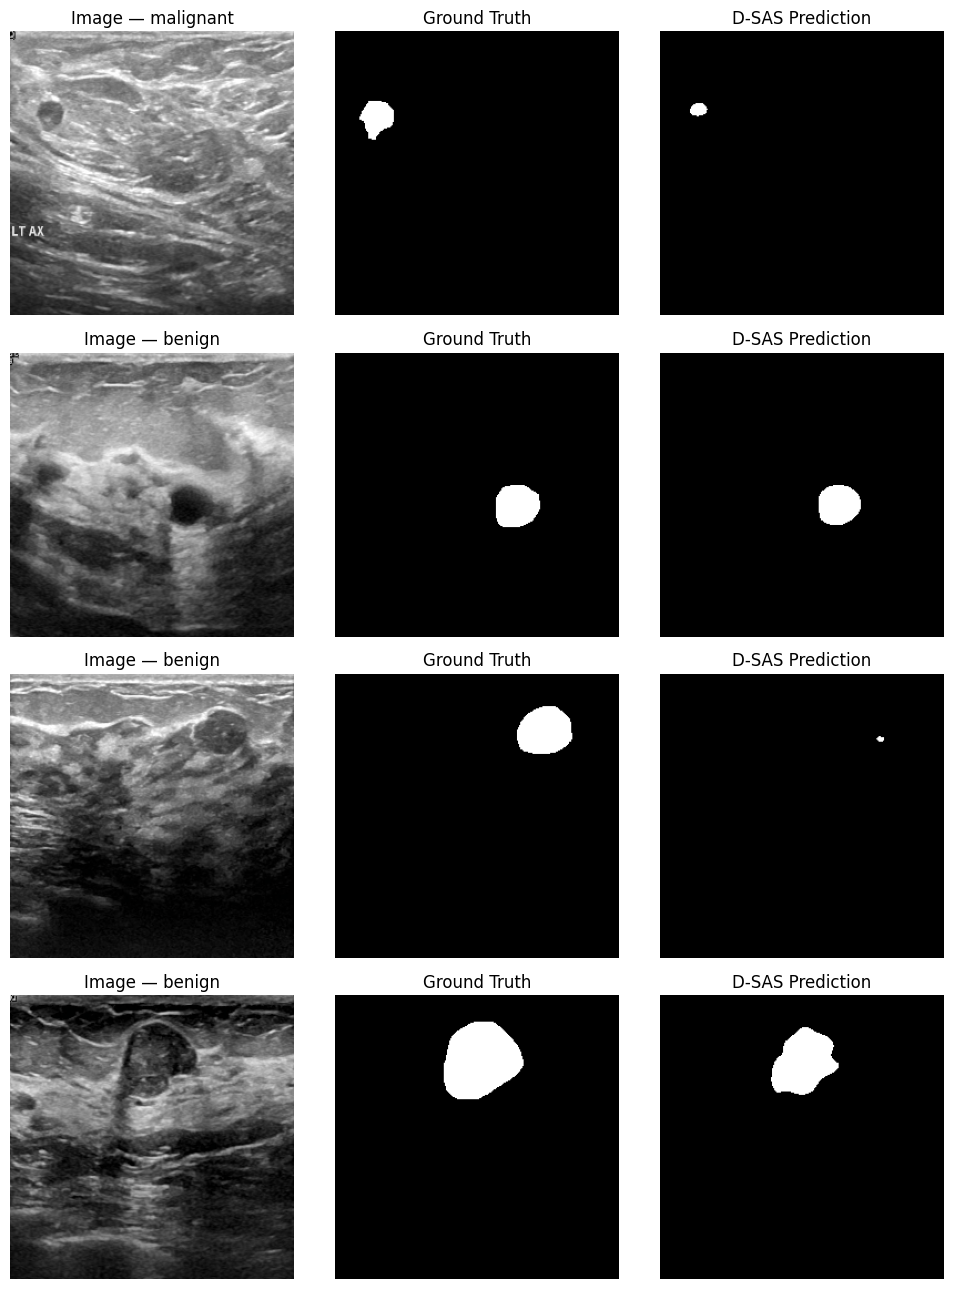

In [34]:
dsas_model.eval()
batch = next(iter(test_loader))
images, masks = batch["image"].to(device), batch["mask"].to(device)
with torch.no_grad():
    preds = torch.sigmoid(dsas_model(images)) > 0.5

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()
    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("D-SAS Prediction"); axes[i, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{DSAS_PROJECT_DIR}/logs/sample_predictions.png', dpi=120)
plt.show()